# Lecture 7.4a: Ptychography — extended Ptychographic Iterative Engine (ePIE)

This lecture introduces **ptychography**, a powerful phase-contrast imaging technique used in 4D-STEM. We implement the **ePIE** (extended Ptychographic Iterative Engine) algorithm to simultaneously reconstruct the sample's electrostatic potential and the electron probe shape from a set of diffraction patterns.

## Learning Objectives
1. Understand the strong-phase approximation and the mathematical basis of the ePIE algorithm.
2. Load and preprocess a 4D-STEM dataset for ptychographic reconstruction.
3. Reconstruct the sample transmission function and probe shape iteratively.
4. Understand how incorrect experimental parameters (rotation angle, reciprocal-space calibration) degrade the reconstruction.
5. Improve results using more iterations, probe position correction, and mixed-state (partially coherent) probes.

## Table of Contents <a name="toc"/>

| # | Section |
|---|---------|
| 1 | [Introduction](#intro) |
| 2 | [Methodology](#meth) |
| 3 | [Setup & Prerequisites](#prep) |
| 4 | [Read Data and Set Experimental Parameters](#load) |
| 5 | [Initialize Probe and Probe Positions](#probe) |
| 6 | [Set Reconstruction Parameters](#recon_param) |
| 7 | [Reconstruction](#recon) |
| — | 7a. [First Pass](#first) |
| — | 7b. [Monitor Probe and Object Convergence](#plot) |
| — | 7c. [Compare to ADF Image](#compare) |
| 8 | [What Can Go Wrong?](#wrong_param) |
| 9 | [Further Improvements: Position Refinement](#improve) |
| 10 | [Higher Resolution: Multiple Probe Modes (Optional)](#multiple) |

## 1. Introduction <a name="intro"/> 

Ptychography is a phase-contrast imaging technique and provides advantages in super-high resolution, high contrast and signal-to-noise, especially for samples containing elements with low atomic numbers or easily damaged during beam irradiation. Recently, a record resolution of 0.04 nm has been demonstrated, which is about 2.5 times better than conventional annular dark-field (ADF) images under similar conditions. The following images show the significant resolution improvement of ptychography (Ptycho) compared to ADF images from a twisted bilayer MoS$_2$ sample [Nature 559, 343 (2018)].

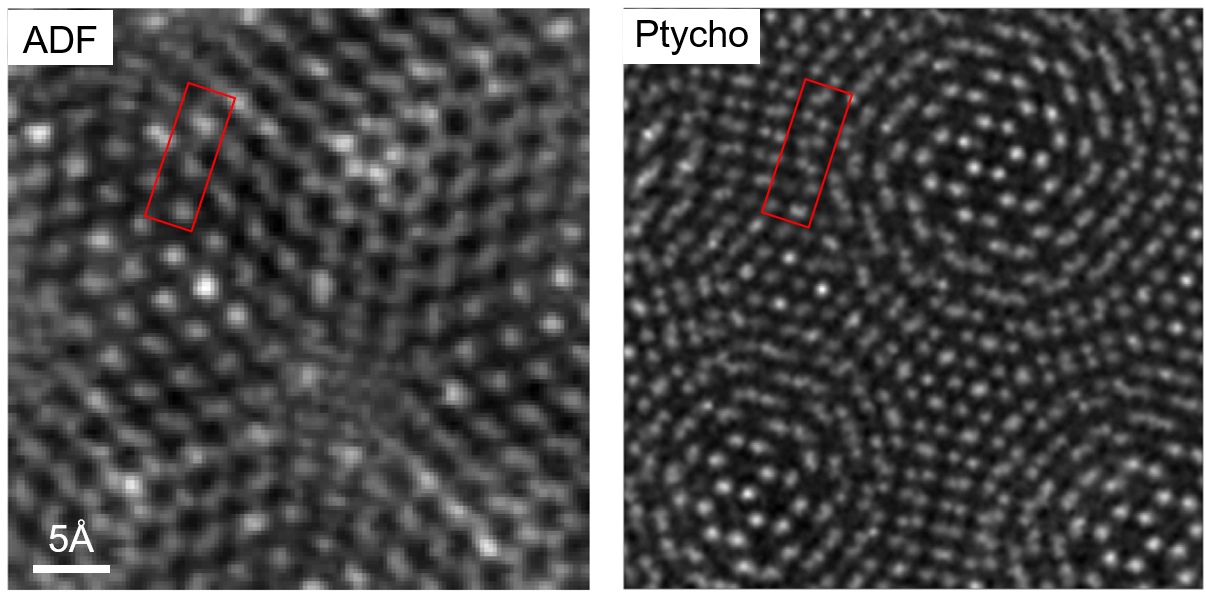

In this tutorial, we will learn how to do ptychography properly using the extended Ptychographic Iterative Engine (ePIE) approach [ref. Ultramicroscopy 109, 1256 (2009)]. In this approach, the sample structure (object function) and the probe shape can be iteratively reconstructed from 4D-STEM dataset. High frequency structural information can be retrieved from diffraction data with residual aberrations of the probe removed. Therefore, the spatial-resolution of the image is much higher than conventional STEM images. We will only consider thin samples such as 2D materials. For thicker samples, multiple scattering should be considered and the algorithm needs to be extended - reference to our recent paper [Z. Chen et al., Science 372, 826 (2021)].

[go to top](#toc)

## 2. Methodology <a name="meth"/> 

In thin samples, exit wave function [$\psi_{exit}(\vec r)$] can be calculated directly from the multiplication of the incident probe [$\psi_{probe}(\vec r)$] and the object (sample) transimission function [$O(\vec r)$], i.e., strong phase approximation. The measured diffraction patterns are the intensity of the exit wave in Fourier space.

$$
\psi_{exit}(\vec r) = \psi_{probe}(\vec r) \cdot O(\vec r)
$$

$$
I(k) = |FT[\psi_{exit}(\vec r)]|^{2}
$$

$$
O(\vec r) = A(\vec r) exp[i \sigma V(\vec r)]
$$

The phase of the object function is proportional to the electrostatic potential [$ V(\vec r)$] and contains the structural information of the sample.

ePIE uses an iterative approach, a simple flowchart is shown below. It starts from an initial object and a probe. The initial object is usually generated with random numbers. The initial probe can be calculated from estimated aberration parameters. The intensity of the modelled diffraction patterns is modified iteratively to match that from the measured patterns. When the difference is sufficiently small, we can obtain the correct probe shape and the sample structure.

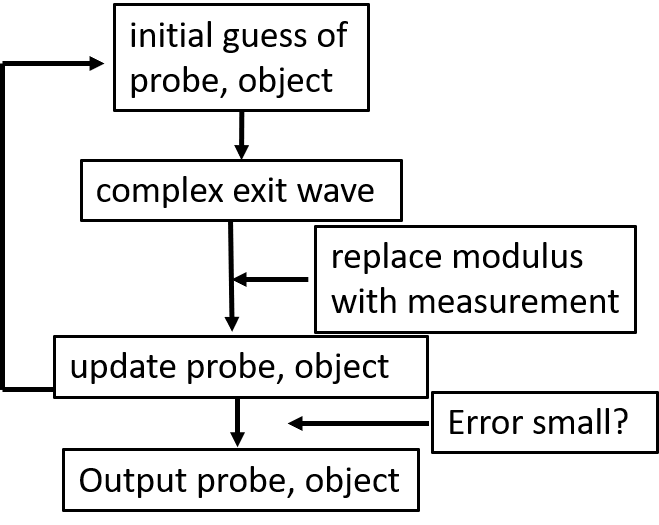

The central part of ePIE algorithm is the estimates of new probe and object function during each iteration. 

$$
O_{j+1}(\textbf{r}) = O_{j}(\textbf{r})+\alpha \frac{P_{j}^{*}(\textbf{r}-\textbf{R}_{s(j)})}{|P_{j}^{*}(\textbf{r}-\textbf{R}_{s(j)})|_{max}^{2}} (\psi_{j}^{'}(\textbf{r})-\psi_{j}(\textbf{r}))
$$

$$
P_{j+1}(\textbf{r}) = P_{j}(\textbf{r})+\beta \frac{O_{j}^{*}(\textbf{r}+\textbf{R}_{s(j)})}{|O_{j}^{*}(\textbf{r}+\textbf{R}_{s(j)})|_{max}^{2}} (\psi_{j}^{'}(\textbf{r})-\psi_{j}(\textbf{r}))
$$

The parameters $\alpha$ and $\beta$ control the update speed and can affect the quality of the results. s(j) is the random sequence that sets the probe position picked at iteration j.

We will use a 4D-STEM data taken from a monolayer MoS$_2$ sample as an example. The sample data contains 31 × 26 diffraction patterns, and there is a single sulfur vacancy in the scanned region. A decent reconstruction needs 20 iterations, which takes about 1-2 minutes. We will use the demo ePIE code written in python. The main routines are put in ePIE_code/ptycho_recon folder. ptycho.py defines parameters and contains some pre-processing and pie_mixed_states.py does the main reconstruction.

### Think about the following questions and try to answer them after the tutorial:

<span style="color:blue"> 1). How are we utilizing the scattering information in the entire diffraction pattern to reconstruct the real-space image? What is the difference between ptychography and ADF imaging?  </span> <br>

<span style="color:blue"> 2). What does the probe shape look like? Is the probe actually aberration free after the aberration correction on the scope?   </span> <br>

<span style="color:blue"> 3). What can we learn about the sample structure from ptychography?  </span> <br>


[go to top](#toc)

## 3. Setup & Prerequisites <a name="prep"/>

### Required helper code
This notebook relies on a set of helper modules. Place them in `./helper/ePIE_code/ptycho_recon/` **relative to this notebook file**. The modules needed are:
- `ptycho.py` — defines the `ptycho` reconstruction class and parameters
- `utility_function.py` (`utils`) — data preprocessing helpers (background removal, scan position calculation, ADF image)
- `probe.py` — STEM probe generation from aberration parameters
- `postProcess.py` — post-processing and cropping of reconstructed objects
- `browser.py` — interactive 4D dataset browser

### Required data
The MoS₂ 4D-STEM dataset is in the **same folder as this notebook**:
- `MoS2_4D_data_step2x_crop_3x3uc.mat` — 4D diffraction dataset  
  (31 × 26 scan positions, 128 × 128 detector pixels, monolayer MoS₂ with one S vacancy)

Results will be saved to `./results/`.

> **Note:** A full reconstruction (20 iterations) takes ~1–2 minutes on a modern laptop CPU.

In [ ]:
# --- Standard library ---
import sys
import os
import time

# --- Scientific stack ---
import numpy as np
from numpy import squeeze, floor, ceil
import scipy.io as sio
import scipy.ndimage          # replaces deprecated scipy.ndimage.filters

# --- Plotting ---
import matplotlib.pyplot as plt
%matplotlib widget

# --- Add ePIE helper modules to path ---
sys.path.append("./helper/ePIE_code/ptycho_recon")

import ptycho as pty
import utility_function as utils
import probe as probe
import postProcess as postProcess
import browser
from IPython.display import HTML

print("All imports successful.")

[go to top](#toc)
## 4. Read Data and Set Experimental Parameters <a name="load"/>

1. Input the path to the 4D dataset here 
2. Set parameters for preprocessing and size of the diffraction patterns (default vaules, can be changed) 
3. Load or enter different experimental parameters (critical for proper reconstruction) 

In [ ]:
print("Input data path and some data related parameters")

######################################### Parameters ##################################### 

data_name = 'MoS2_4D_data_step2x_crop_3x3uc.mat'
data_dir = './'                # data file is in the same folder as this notebook
results_dir = './results/'
result_dir_extra0 = 'run1'  # string for specific output folder name

N_roi = 128 #Size of square diffraction patterns
rot_angle_d = 30 #(degree) Rotation angle between real space and diffraction space coordinates

ADU_background_cutoff = 20 #Threshold that below which would be removed
ADU_electronCount_ratio = 151.0 # factor needed to convert between detector output and actual electron counts 


##################################### read data ########################################
path = os.getcwd()
data = sio.loadmat(data_dir + data_name)
print('variables loaded:')
print(data.keys())

Input data path and some data related parameters
variables loaded:
dict_keys(['__header__', '__version__', '__globals__', 'adf', 'alpha_max', 'crop_idx', 'cs', 'df', 'dk', 'dp', 'lambda', 'scanStepSize_x', 'scanStepSize_y', 'voltage'])


The *.mat data file contains the 4D STEM dataset (dp), probe forming semi-angle (alpha_max), spherical aberration (cs), focus (df), pixel size in diffraction plane (dk), scan step size (scanStepSize_x/y), and beam voltage (voltage). 


In [3]:
dp = data['dp']*1.0 #4D Diffraction patterns

N_dp = dp.shape[0]

# parameters read from example *.mat file 
# if any of parameters need to be changed, mannually input the corresponding variable

voltage = squeeze(data['voltage']) # kev
alpha_max = squeeze(data['alpha_max']) # mrad
df = squeeze(data['df']) # defocus (angstrom)
cs = squeeze(data['cs']) # spherical aberration (mm)
scanStepSize_x = squeeze(data['scanStepSize_x'])
scanStepSize_y = squeeze(data['scanStepSize_y'])

dk = squeeze(data['dk']) # reciprocal space pixel size (inverse angstrom)
print("dk =", dk)
dx = 1.0/dk/N_roi # real space pixel size (angstrom)
print("dx =", dx)

################################## data processing ##########################################
print("processing data")


result_dir_extra = "_preprocessCBED" #Directory name of output
dp, result_dir_extra = utils.transpose_cbed(dp, result_dir_extra) #Transpose scan direction x & y and update the directory name


#Set pixels that are less than threshold to 0 and update directory name
dp, result_dir_extra = utils.background_removal(dp, ADU_background_cutoff, result_dir_extra)

print("recon data size:", dp.shape)

dk = 0.033064825413611276
dx = 0.23627827766433485
processing data
transpose cbed patterns
removing background: threshold= 20
recon data size: (124, 124, 31, 26)


Raw experimental data may need some pre-processing, such as matrix rotation or transpose or background removing. Related functions can be found in utility_function.py. 

### What does the 4D data look like?

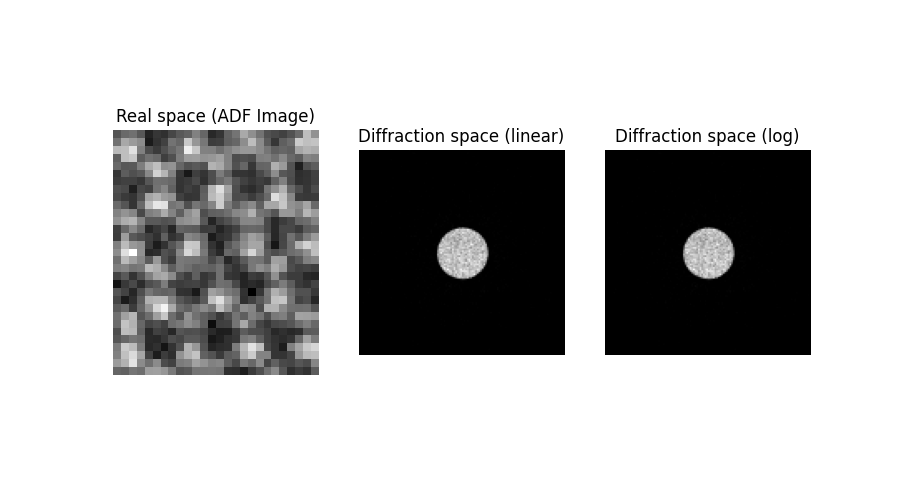

In [4]:
guis=browser.browser( np.transpose(dp, (2,3,0,1)) ) #function expects real space coordinates first

A short video to remind you of the experimental parameters and how the diffraction pattern looks as the beam is scanned over the sample.

In [5]:
from IPython.display import HTML

HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="./helper/Media/pty_video.mp4" type="video/mp4">
</video></div>""")

[go to top](#toc)
## 5. Initialize probe and probe positions <a name="probe"/>
Before we start ptychography, we need an initial probe and define the coordinates of the probe positions.

In [6]:
################################## make initial probe function ##################################
probe_init = probe.STEMprobe()
probe_init.df = df
probe_init.cs = cs
probe_init.alpha_max = alpha_max
probe_init.voltage = voltage

################################## calculate scan positions ####################################
#calculate scan positions
N_scan_y = dp.shape[2]
N_scan_x = dp.shape[3]

#Generate the arrays of the scanning positions after scanning rotation correction and update the info in the directory
ppX, ppY, result_dir_extra = utils.calculate_scan_positions(N_scan_x, N_scan_y, scanStepSize_x, scanStepSize_y, rot_angle_d, result_dir_extra)

Ny_max = max([abs(round(np.min(ppY)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppY)/dx)+ceil(N_roi/2.0))])*2+1
Nx_max = max([abs(round(np.min(ppX)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppX)/dx)+ceil(N_roi/2.0))])*2+1

#Extend the size of the object to accommondate position correction, and will crop later
N_image = int(max([Ny_max,Nx_max]))+20
print("Image size:", N_image)

calculate scan positions
N_scan_x = 26 scanStepSize_x = 0.42
N_scan_y = 31 scanStepSize_y = 0.42
rot_angle = 30
Image size: 219


[go to top](#toc)
## 6. Set reconstruction parameters <a name="recon_param"/>
The major ptychography routine calls a class variable called reconObject. Parameters are input into paraDict. Some important parameters must be set. Other parameters (that are set by default) can be found in ptycho.py.

In [7]:
########################################### reconstruction #####################################
print('Set reconstruction parameters')

reconObject = pty.ptycho(dp, dk, probe_init, ppX, ppY)
reconObject.paraDict['dk_y'] = dk
reconObject.paraDict['dk_x'] = dk
reconObject.paraDict['N_image'] = N_image 
reconObject.paraDict['N_roi'] = N_roi #Size of ROI
reconObject.paraDict['rotationAngle']  = rot_angle_d

reconObject.paraDict['Niter'] = 20 #Number of iterations
reconObject.paraDict['Niter_update_probe'] = 0 #Update probe from the 1st iteration
reconObject.paraDict['Niter_save'] = 5 #How often to save the reconstruction results


reconObject.paraDict['beta'] = 1 #Learning rate for updating probe
reconObject.paraDict['alpha'] = 0.1 #Learning rate for updating object


reconObject.paraDict['printID'] = 'MoS2' #sample label

Set reconstruction parameters


[go to top](#toc)
## 7. Reconstruction <a name="recon"/>

### a). First pass <a name="first"/>

In [8]:
################################################################
result_dir = results_dir + "/mos2_" + result_dir_extra0 # Location to save results
result_dir_extra = reconObject.initialize(result_dir) # Initialize the class variable and load the predefined parameters 


start_time = time.time()
reconObject.recon() #start reconstruction
total_time = time.time() - start_time


timeLeftMin, timeLeftSec = divmod(total_time, 60)
timeLeftHour, timeLeftMin = divmod(timeLeftMin, 60)
print('Total recon time: %02d:%02d:%02d' %(timeLeftHour,timeLeftMin,timeLeftSec))


generating probe function...
begin ptychographic reconstruction
MoS2-Iter:0 Time remain: 00:00:00
start probe update
MoS2-Iter:1 Time remain: 00:00:34
MoS2-Iter:2 Time remain: 00:00:32
MoS2-Iter:3 Time remain: 00:00:30
MoS2-Iter:4 Time remain: 00:00:28
MoS2-Iter:5 Time remain: 00:00:26
MoS2-Iter:6 Time remain: 00:00:24
MoS2-Iter:7 Time remain: 00:00:22
MoS2-Iter:8 Time remain: 00:00:20
MoS2-Iter:9 Time remain: 00:00:19
MoS2-Iter:10 Time remain: 00:00:17
MoS2-Iter:11 Time remain: 00:00:15
MoS2-Iter:12 Time remain: 00:00:13
MoS2-Iter:13 Time remain: 00:00:12
MoS2-Iter:14 Time remain: 00:00:10
MoS2-Iter:15 Time remain: 00:00:08
MoS2-Iter:16 Time remain: 00:00:06
MoS2-Iter:17 Time remain: 00:00:05
MoS2-Iter:18 Time remain: 00:00:03
MoS2-Iter:19 Time remain: 00:00:01
Total recon time: 00:00:35


### CHECKPOINT : 

While the reconstruction runs, think about these questions:

   <span style="color:blue"> 1). How do you generate a initial STEM probe function? </span> <br> 

   <span style="color:blue"> 2). How can we define the coordinates of probe positions? </span> <br> 

[go to top](#toc)
### b) Monitor the probe and object change <a name="plot"/>
 
 Check whether the reconstruction is converging to the correct probe and object from the random/ideal ones we started with.

./data/results//mos2_run1/recon_Niter5.mat
./data/results//mos2_run1/recon_Niter10.mat
./data/results//mos2_run1/recon_Niter15.mat
./data/results//mos2_run1/recon_Niter20.mat


./helper/ePIE_code/ptycho_recon/postProcess.py:32: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coeff, r, rank, s = np.linalg.lstsq(A, B)


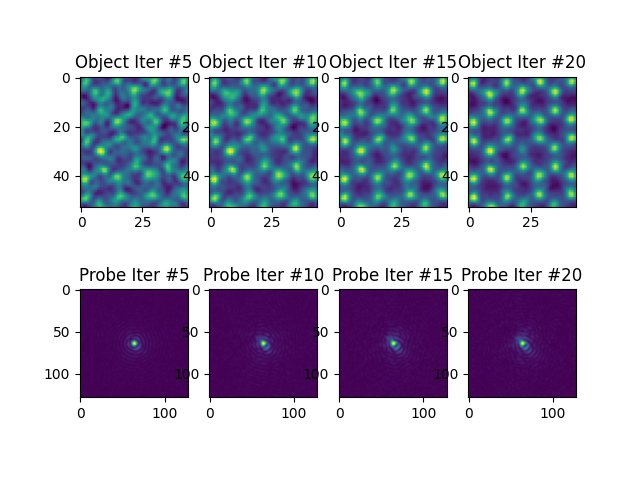

In [9]:
os.chdir(path)

Niters=[5,10,15,20]  # read in results from some iterations

fig2, ax2 = plt.subplots(nrows=2, ncols=len(Niters))
plt.figure(1)

for kk in range(len(Niters)):
    prev_recon_name = results_dir + "/mos2_" + result_dir_extra0 + "/" + "recon_Niter" + str(Niters[kk]) + ".mat"
    prev_recon_data = sio.loadmat(prev_recon_name)
    print(prev_recon_name)
    obj=prev_recon_data['object']
    prb=prev_recon_data['probes']
    px = prev_recon_data['ppX']
    py = prev_recon_data['ppY']
    dx_val = prev_recon_data['dx_x']
    obj_crop = postProcess.postProcess(obj, rot_angle_d, px, py, dx_val)
    ax2[0,kk].imshow( np.angle(obj_crop) )
    ax2[0,kk].set_title('Object Iter #' + str(Niters[kk]) )   
    for jj in range(prb.shape[0]):
        ax2[jj+1,kk].imshow( np.abs(prb[jj,:,:]) )
        if prb.shape[0] == 1 :
            title_str='Probe Iter #' + str(Niters[kk])
        else:                
            title_str='Probe Mode #' + str(jj+1)
        ax2[jj+1,kk].set_title(title_str) 
        

[go to top](#toc)
### c) . Sample structure from ptychography: Compare to ADF  <a name="compare"/>


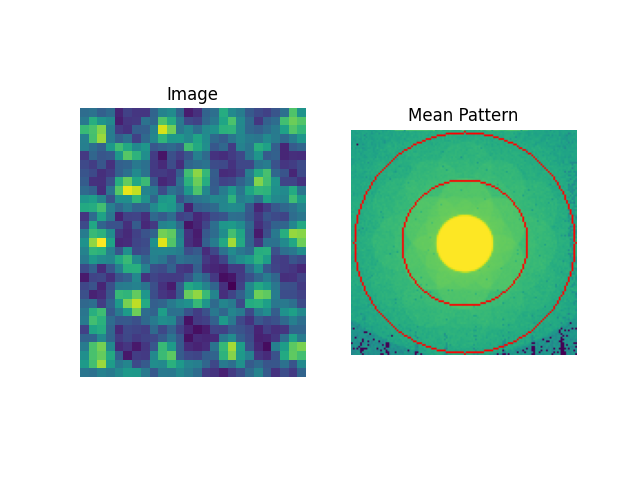

In [10]:
r0=35 #inner radius
r1=60 #outer radius

ADF = utils.adf_image(dp, [r0,r1])

./data/results//mos2_run1/recon_Niter20.mat


Text(0.5, 1.0, 'Pty lineprofile Iter #20')

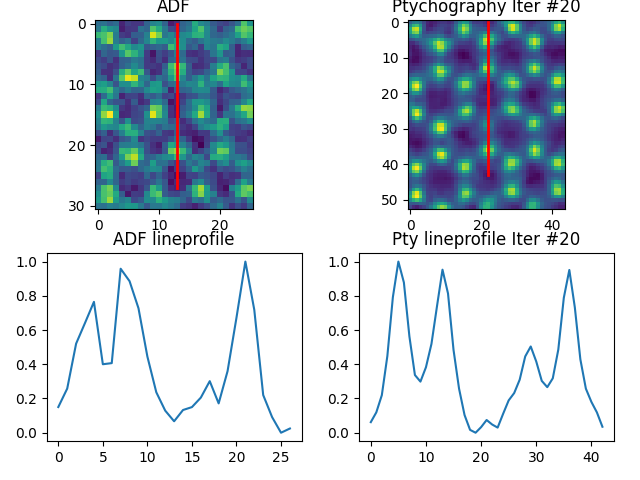

In [11]:
os.chdir(path)
N_iter = 20
prev_recon_name = results_dir + "/mos2_" + result_dir_extra0 + "/" +  "recon_Niter" + str(N_iter) + ".mat"
prev_recon_data = sio.loadmat(prev_recon_name)
print(prev_recon_name)
obj = prev_recon_data['object']
px = prev_recon_data['ppX']
py = prev_recon_data['ppY']
dx_val = prev_recon_data['dx_x']
obj_crop = postProcess.postProcess(obj, rot_angle_d, px, py, dx_val)

#Line profile coordinates for ptychography reconstruction

x_min_pty = 0
x_max_pty = 43
y_min_pty = 21
y_max_pty = 24
y_mean_pty = int ( (y_min_pty + y_max_pty) / 2)

sum_axis = 1
linewidth_pty = 1

if(sum_axis == 1):
    linewidth_pty = y_max_pty - y_min_pty - 1
else:
    linewidth_pty = x_max_pty - x_min_pty - 1


pty_m = np.mean(np.angle(obj_crop[x_min_pty:x_max_pty,y_min_pty:y_max_pty]), axis = sum_axis )
pty_m = ( pty_m - pty_m.min() ) / ( pty_m.max() - pty_m.min() )

#Line profile coordinates for ADF image

x_min_ADF = 0
x_max_ADF = 27
y_min_ADF = 12
y_max_ADF = 15
y_mean_ADF = int ( (y_min_ADF + y_max_ADF) / 2)
sum_axis = 1

linewidth_ADF = 1

if(sum_axis == 1):
    linewidth_ADF = y_max_ADF - y_min_ADF - 1
else:
    linewidth_ADF = x_max_ADF - x_min_ADF - 1
    
ADF_m = np.mean(ADF[x_min_ADF:x_max_ADF,y_min_ADF:y_max_ADF], axis = sum_axis )
ADF_m = ( ADF_m - ADF_m.min() ) / ( ADF_m.max() - ADF_m.min() )



fig0, ax0 = plt.subplots(nrows=2, ncols=2)
fig0.tight_layout()
ax0[0,0].imshow(ADF)
ax0[0,0].set_title('ADF')  
ax0[0,0].plot([y_mean_ADF, y_mean_ADF], [x_min_ADF,x_max_ADF], linewidth = linewidth_ADF, color = 'red')

ax0[1,0].plot(range(27),ADF_m)
ax0[1,0].set_title('ADF lineprofile')

ax0[0,1].imshow(np.angle(obj_crop) )
ax0[0,1].set_title('Ptychography Iter #' + str(N_iter) )   
ax0[0,1].plot([y_mean_pty, y_mean_pty], [x_min_pty,x_max_pty], linewidth = linewidth_pty, color = 'red')

ax0[1,1].plot(range(43),pty_m)
ax0[1,1].set_title('Pty lineprofile Iter #' + str(N_iter))

[go to top](#toc)

## 8. What can go wrong?  <a name="wrong_param"/> 

Since there are quite a lot of experimental and reconstruction parameters, using correct parameters is critical for a correct/good reconstruction. Let us go through two examples where we feed wrong parameters.

### a). Wrong rotation angle

Rotation angle is set to 0 instead of 30 degrees. This shows the importance of knowing the relative orientation of scan coordinates and diffraction space coordinates.

In [12]:
rot_angle_new = 0

#Generate the arrays of the scanning positions after scanning rotation correction and update the info in the directory
ppX, ppY, result_dir_extra = utils.calculate_scan_positions(N_scan_x, N_scan_y, scanStepSize_x, scanStepSize_y, rot_angle_new, result_dir_extra)

Ny_max = max([abs(round(np.min(ppY)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppY)/dx)+ceil(N_roi/2.0))])*2+1
Nx_max = max([abs(round(np.min(ppX)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppX)/dx)+ceil(N_roi/2.0))])*2+1

reconObject = pty.ptycho(dp, dk, probe_init, ppX, ppY)
reconObject.paraDict['dk_y'] = dk
reconObject.paraDict['dk_x'] = dk
reconObject.paraDict['N_image'] = N_image 
reconObject.paraDict['N_roi'] = N_roi #Size of ROI
reconObject.paraDict['Niter'] = 20 #Number of iterations
reconObject.paraDict['Niter_update_probe'] = 0 #Update probe from the 1st iteration
reconObject.paraDict['Niter_save'] = 5 #How often to save the reconstruction results

reconObject.paraDict['beta'] = 1 #Learning rate for updating probe
reconObject.paraDict['alpha'] = 0.1 #Learning rate for updating object

reconObject.paraDict['rotationAngle']  = rot_angle_new

reconObject.paraDict['printID'] = 'MoS2' #sample label


calculate scan positions
N_scan_x = 26 scanStepSize_x = 0.42
N_scan_y = 31 scanStepSize_y = 0.42
rot_angle = 0


In [13]:
################################################################
result_dir = results_dir + "/mos2_" + "wrong_rotate0_" + result_dir_extra0
result_dir_extra = reconObject.initialize(result_dir) #Load the predefined parameters


start_time = time.time()
reconObject.recon() #start reconstruction
total_time = time.time() - start_time

timeLeftMin, timeLeftSec = divmod(total_time, 60)
timeLeftHour, timeLeftMin = divmod(timeLeftMin, 60)
print('Total recon time: %02d:%02d:%02d' %(timeLeftHour,timeLeftMin,timeLeftSec))

generating probe function...
begin ptychographic reconstruction
MoS2-Iter:0 Time remain: 00:00:00
start probe update
MoS2-Iter:1 Time remain: 00:00:33
MoS2-Iter:2 Time remain: 00:00:31
MoS2-Iter:3 Time remain: 00:00:29
MoS2-Iter:4 Time remain: 00:00:27
MoS2-Iter:5 Time remain: 00:00:25
MoS2-Iter:6 Time remain: 00:00:24
MoS2-Iter:7 Time remain: 00:00:22
MoS2-Iter:8 Time remain: 00:00:20
MoS2-Iter:9 Time remain: 00:00:19
MoS2-Iter:10 Time remain: 00:00:17
MoS2-Iter:11 Time remain: 00:00:15
MoS2-Iter:12 Time remain: 00:00:13
MoS2-Iter:13 Time remain: 00:00:12
MoS2-Iter:14 Time remain: 00:00:10
MoS2-Iter:15 Time remain: 00:00:08
MoS2-Iter:16 Time remain: 00:00:06
MoS2-Iter:17 Time remain: 00:00:05
MoS2-Iter:18 Time remain: 00:00:03
MoS2-Iter:19 Time remain: 00:00:01
Total recon time: 00:00:34


./data/results//mos2_wrong_rotate0_run1/recon_Niter5.mat
./data/results//mos2_wrong_rotate0_run1/recon_Niter10.mat
./data/results//mos2_wrong_rotate0_run1/recon_Niter15.mat
./data/results//mos2_wrong_rotate0_run1/recon_Niter20.mat


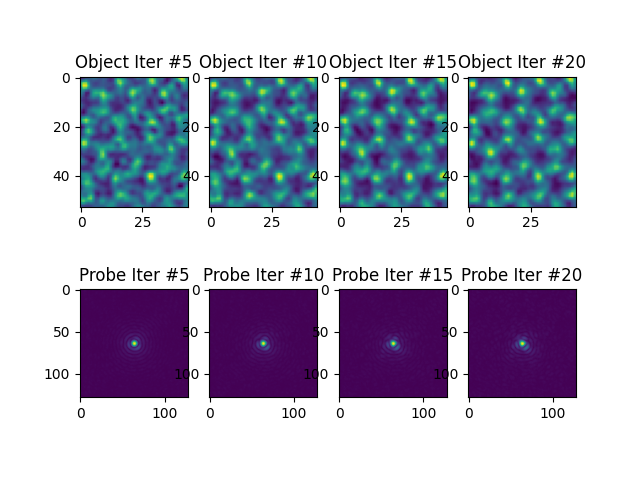

In [14]:
os.chdir(path)

Niters=[5,10,15,20]  # read in results from some iterations
fig2, ax2 = plt.subplots(nrows=2, ncols=len(Niters))
plt.figure(1)
for kk in range(len(Niters)):
    prev_recon_name = results_dir + "/mos2_" + "wrong_rotate0_" + result_dir_extra0 + "/" + "recon_Niter" + str(Niters[kk]) + ".mat"
    prev_recon_data = sio.loadmat(prev_recon_name)
    print(prev_recon_name)
    obj=prev_recon_data['object']
    prb=prev_recon_data['probes']
    px = prev_recon_data['ppX']
    py = prev_recon_data['ppY']
    dx_val = prev_recon_data['dx_x']
    obj_crop = postProcess.postProcess(obj, rot_angle_new, px, py, dx_val)
    ax2[0,kk].imshow( np.angle(obj_crop) )
    ax2[0,kk].set_title('Object Iter #' + str(Niters[kk]) )   
    for jj in range(prb.shape[0]):
        ax2[jj+1,kk].imshow( np.abs(prb[jj,:,:]) )
        if prb.shape[0] == 1 :
            title_str='Probe Iter #' + str(Niters[kk])
        else:                
            title_str='Probe Mode #' + str(jj+1)
        ax2[jj+1,kk].set_title(title_str) 
        

### b). Wrong reciprocal space sampling:

Let us change dk to 70% of correct value and see what happens.

In [15]:
os.chdir(path)
#Generate the arrays of the scanning positions after scanning rotation correction and update the info in the directory
ppX, ppY, result_dir_extra = utils.calculate_scan_positions(N_scan_x, N_scan_y, scanStepSize_x, scanStepSize_y, rot_angle_d, result_dir_extra)

Ny_max = max([abs(round(np.min(ppY)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppY)/dx)+ceil(N_roi/2.0))])*2+1
Nx_max = max([abs(round(np.min(ppX)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppX)/dx)+ceil(N_roi/2.0))])*2+1

reconObject = pty.ptycho(dp, dk * 0.5, probe_init, ppX, ppY)
reconObject.paraDict['dk_y'] = dk * 0.7
reconObject.paraDict['dk_x'] = dk * 0.7
reconObject.paraDict['N_image'] = N_image 
reconObject.paraDict['N_roi'] = N_roi #Size of ROI
reconObject.paraDict['Niter'] = 20 #Number of iterations
reconObject.paraDict['Niter_update_probe'] = 0 #Update probe from the 1st iteration
reconObject.paraDict['Niter_save'] = 5 #How often to save the reconstruction results

reconObject.paraDict['beta'] = 1 #Learning rate for updating probe
reconObject.paraDict['alpha'] = 0.1 #Learning rate for updating object

reconObject.paraDict['rotationAngle']  = rot_angle_d

reconObject.paraDict['printID'] = 'MoS2' #sample label


calculate scan positions
N_scan_x = 26 scanStepSize_x = 0.42
N_scan_y = 31 scanStepSize_y = 0.42
rot_angle = 30


In [16]:
################################################################
result_dir = results_dir + "/mos2_" + "wrong_dk_70percent_" + result_dir_extra0
result_dir_extra = reconObject.initialize(result_dir) #Load the predefined parameters


start_time = time.time()
reconObject.recon() #start reconstruction
total_time = time.time() - start_time

timeLeftMin, timeLeftSec = divmod(total_time, 60)
timeLeftHour, timeLeftMin = divmod(timeLeftMin, 60)
print('Total recon time: %02d:%02d:%02d' %(timeLeftHour,timeLeftMin,timeLeftSec))

generating probe function...
begin ptychographic reconstruction
MoS2-Iter:0 Time remain: 00:00:00
start probe update
MoS2-Iter:1 Time remain: 00:00:34
MoS2-Iter:2 Time remain: 00:00:31
MoS2-Iter:3 Time remain: 00:00:29
MoS2-Iter:4 Time remain: 00:00:28
MoS2-Iter:5 Time remain: 00:00:26
MoS2-Iter:6 Time remain: 00:00:24
MoS2-Iter:7 Time remain: 00:00:22
MoS2-Iter:8 Time remain: 00:00:20
MoS2-Iter:9 Time remain: 00:00:19
MoS2-Iter:10 Time remain: 00:00:17
MoS2-Iter:11 Time remain: 00:00:15
MoS2-Iter:12 Time remain: 00:00:13
MoS2-Iter:13 Time remain: 00:00:12
MoS2-Iter:14 Time remain: 00:00:10
MoS2-Iter:15 Time remain: 00:00:08
MoS2-Iter:16 Time remain: 00:00:07
MoS2-Iter:17 Time remain: 00:00:05
MoS2-Iter:18 Time remain: 00:00:03
MoS2-Iter:19 Time remain: 00:00:01
Total recon time: 00:00:35


./data/results//mos2_wrong_dk_70percent_run1/recon_Niter5.mat
./data/results//mos2_wrong_dk_70percent_run1/recon_Niter10.mat
./data/results//mos2_wrong_dk_70percent_run1/recon_Niter15.mat
./data/results//mos2_wrong_dk_70percent_run1/recon_Niter20.mat


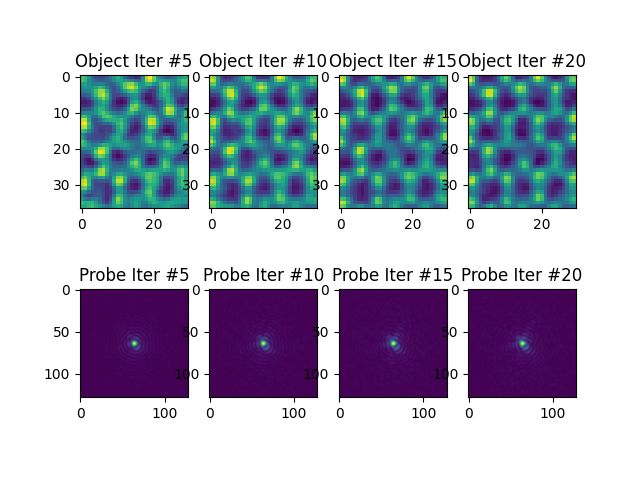

In [17]:
os.chdir(path)

Niters=[5,10,15,20]  # read in results from some iterations
fig2, ax2 = plt.subplots(nrows=2, ncols=len(Niters))

plt.figure(1)
for kk in range(len(Niters)):
    prev_recon_name = results_dir + "/mos2_" + "wrong_dk_70percent_" + result_dir_extra0 + "/" + "recon_Niter" + str(Niters[kk]) + ".mat"
    prev_recon_data = sio.loadmat(prev_recon_name)
    print(prev_recon_name)
    obj=prev_recon_data['object']
    prb=prev_recon_data['probes']
    px = prev_recon_data['ppX']
    py = prev_recon_data['ppY']
    dx_val = prev_recon_data['dx_x']
    obj_crop = postProcess.postProcess(obj, rot_angle_d, px, py, dx_val)
    ax2[0,kk].imshow( np.angle(obj_crop) )
    ax2[0,kk].set_title('Object Iter #' + str(Niters[kk]) )   
    for jj in range(prb.shape[0]):
        ax2[jj+1,kk].imshow( np.abs(prb[jj,:,:]) )
        if prb.shape[0] == 1 :
            title_str='Probe Iter #' + str(Niters[kk])
        else:                
            title_str='Probe Mode #' + str(jj+1)
        ax2[jj+1,kk].set_title(title_str) 
        

### CHECKPOINT

We have now seen how to do basic reconstructions with a few iterations. We also saw how wrong values of parameters can completely ruin the reconstruction quality. Think about the following questions before we move onto the next step where we will further refine our results.

<span style="color:blue"> Why does wrong rotation angle degrade the reconstruction result?
    
<span style="color:blue"> Why does wrong dk degrade the reonstruction result?

[go to top](#toc)
## 9. Further improvements with more iterations and position refinement <a name="improve"/>
<span style="color:red"> Since we have changed parameters in the previous session, we will first need to restore the correct ones before proceeding. </span><br>

The original correct parameters are stored in data (*.mat) file.

In [18]:
## Let's restore the correct parameters from data

alpha_max = squeeze(data['alpha_max']) # mrad
scanStepSize_x = squeeze(data['scanStepSize_x'])
scanStepSize_y = squeeze(data['scanStepSize_y'])
probe_init.alpha_max = alpha_max

N_roi = 128 #Size of square diffraction patterns

dk = squeeze(data['dk']) # reciprocal space pixel size (inverse angstrom)
dx = 1.0/dk/N_roi # real space pixel size (angstrom)
ppX, ppY, result_dir_extra = utils.calculate_scan_positions(N_scan_x, N_scan_y, scanStepSize_x, scanStepSize_y, rot_angle_d, result_dir_extra)

Ny_max = max([abs(round(np.min(ppY)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppY)/dx)+ceil(N_roi/2.0))])*2+1
Nx_max = max([abs(round(np.min(ppX)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppX)/dx)+ceil(N_roi/2.0))])*2+1

#Extend the size of the object to accommondate position correction, and will crop later
N_image = int(max([Ny_max,Nx_max]))+20


reconObject = pty.ptycho(dp, dk, probe_init, ppX, ppY)
reconObject.paraDict['dk_y'] = dk
reconObject.paraDict['dk_x'] = dk
reconObject.paraDict['N_image'] = N_image 
reconObject.paraDict['N_roi'] = N_roi #Size of ROI
reconObject.paraDict['Niter'] = 20 #Number of iterations
reconObject.paraDict['Niter_update_probe'] = 0 #Update probe from the 1st iteration
reconObject.paraDict['Niter_save'] = 5 #How often to save the reconstruction results

reconObject.paraDict['beta'] = 1 #Learning rate for updating probe
reconObject.paraDict['alpha'] = 0.1 #Learning rate for updating object

reconObject.paraDict['rotationAngle']  = rot_angle_d

calculate scan positions
N_scan_x = 26 scanStepSize_x = 0.42
N_scan_y = 31 scanStepSize_y = 0.42
rot_angle = 30


We can use a previous run as a better initial guess to help the reconstruction to converge faster.

Let's grab the path of a good previous run first and load the probes and object as the initial start.

In [19]:
result_dir_extra_opt = 'optimization'

############## load existing probe and object ##############

prev_recon_name = results_dir + "/mos2_" + result_dir_extra0 + "/" + "recon_Niter20.mat"
print(prev_recon_name)

prev_recon_data = sio.loadmat(prev_recon_name)
reconObject.paraDict['probes0'] = prev_recon_data['probes'] #mixed states opr\n",
reconObject.paraDict['previous_obj'] = prev_recon_data['object'] #mixed states opr\n",

./data/results//mos2_run1/recon_Niter20.mat


We can use more iterations and probe position correction to improve the reconstruction. But it needs more time!

In [20]:
reconObject.paraDict['Niter'] = 40 # Number of iterations
reconObject.paraDict['Niter_save'] = 10 # How often to save the reconstruction results
############## position correction ##############
reconObject.paraDict['Niter_update_position'] = 10 # Position correction starts from this iteration

result_dir = results_dir + "/mos2_" + result_dir_extra0 + '_' + result_dir_extra_opt
result_dir_extra = reconObject.initialize(result_dir) # Load the predefined parameters

print(reconObject.paraDict['saveName'])
start_time = time.time()
reconObject.recon() #start reconstruction
total_time = time.time() - start_time

timeLeftMin, timeLeftSec = divmod(total_time, 60)
timeLeftHour, timeLeftMin = divmod(timeLeftMin, 60)
print('Total recon time: %02d:%02d:%02d' %(timeLeftHour,timeLeftMin,timeLeftSec))

generating probe function...
recon
begin ptychographic reconstruction
-Iter:0 Time remain: 00:00:00
start probe update
-Iter:1 Time remain: 00:01:10
-Iter:2 Time remain: 00:01:08
-Iter:3 Time remain: 00:01:06
-Iter:4 Time remain: 00:01:05
-Iter:5 Time remain: 00:01:03
-Iter:6 Time remain: 00:01:01
-Iter:7 Time remain: 00:00:59
-Iter:8 Time remain: 00:00:57
-Iter:9 Time remain: 00:00:55
-Iter:10 Time remain: 00:00:54
start position correction
-Iter:11 Time remain: 00:01:11
-Iter:12 Time remain: 00:01:08
-Iter:13 Time remain: 00:01:06
-Iter:14 Time remain: 00:01:05
-Iter:15 Time remain: 00:01:03
-Iter:16 Time remain: 00:01:01
-Iter:17 Time remain: 00:00:59
-Iter:18 Time remain: 00:00:57
-Iter:19 Time remain: 00:00:54
-Iter:20 Time remain: 00:00:51
-Iter:21 Time remain: 00:00:49
-Iter:22 Time remain: 00:00:46
-Iter:23 Time remain: 00:00:43
-Iter:24 Time remain: 00:00:40
-Iter:25 Time remain: 00:00:38
-Iter:26 Time remain: 00:00:35
-Iter:27 Time remain: 00:00:32
-Iter:28 Time remain: 00:00

Let's plot the results and compare with the previous results.

./data/results//mos2_run1_optimization/recon_Niter40.mat
(219, 219)
dx= [[0.23627828]]
30
(54, 45)


Text(0.5, 1.0, 'Probe')

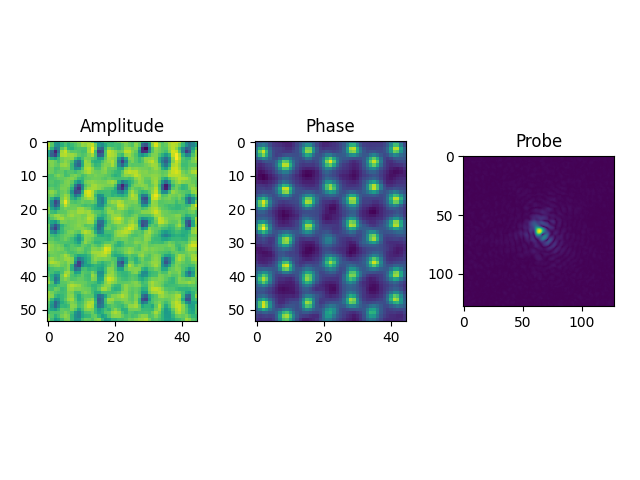

In [21]:
os.chdir(path)
prev_recon_name = results_dir + "/mos2_" + result_dir_extra0+ "_" + result_dir_extra_opt + "/" +  "recon_Niter40" + ".mat"
prev_recon_data = sio.loadmat(prev_recon_name)
print(prev_recon_name)
obj = prev_recon_data['object']
probe = prev_recon_data['probes']
px = prev_recon_data['ppX']
py = prev_recon_data['ppY']
dx = prev_recon_data['dx_x']
print(np.shape(obj))
print("dx=",dx)
print(rot_angle_d)
obj_crop = postProcess.postProcess(obj, rot_angle_d, px, py, dx)

print(np.shape(obj_crop))
fig0, ax0 = plt.subplots(nrows=1, ncols=3)
fig0.tight_layout()
ax0[0].imshow(np.abs(obj_crop))
ax0[0].set_title('Amplitude')      
ax0[1].imshow(np.angle(obj_crop) )
ax0[1].set_title('Phase')   
ax0[2].imshow(np.abs(probe[0,:,:]))
ax0[2].set_title('Probe')      
  

[go to top](#toc)
## 10. Higher resolution using multiple probe modes (optional) <a name="multiple"/>
Even though highly coherent, the electron probe is still not perfectly coherent. The partial coherence can be modeled by using multiple probe modes, i.e., a mixed-state probe.

In [22]:
############## mixed-states reconstruction ############## 
## Let's restore the correct parameters from data

alpha_max = squeeze(data['alpha_max']) # mrad
scanStepSize_x = squeeze(data['scanStepSize_x'])
scanStepSize_y = squeeze(data['scanStepSize_y'])
probe_init.alpha_max = alpha_max

N_roi = 128 #Size of square diffraction patterns

dk = squeeze(data['dk']) # reciprocal space pixel size (inverse angstrom)
dx = 1.0/dk/N_roi # real space pixel size (angstrom)
ppX, ppY, result_dir_extra = utils.calculate_scan_positions(N_scan_x, N_scan_y, scanStepSize_x, scanStepSize_y, rot_angle_d, result_dir_extra)

Ny_max = max([abs(round(np.min(ppY)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppY)/dx)+ceil(N_roi/2.0))])*2+1
Nx_max = max([abs(round(np.min(ppX)/dx)-floor(N_roi/2.0)), abs(round(np.max(ppX)/dx)+ceil(N_roi/2.0))])*2+1

#Extend the size of the object to accommondate position correction, and will crop later
N_image = int(max([Ny_max,Nx_max]))+20


reconObject = pty.ptycho(dp, dk, probe_init, ppX, ppY)
reconObject.paraDict['dk_y'] = dk
reconObject.paraDict['dk_x'] = dk
reconObject.paraDict['N_image'] = N_image 
reconObject.paraDict['N_roi'] = N_roi #Size of ROI
reconObject.paraDict['Niter'] = 40 #Number of iterations
reconObject.paraDict['Niter_update_probe'] = 0 # Update probe from the 1st iteration
reconObject.paraDict['Niter_save'] = 10 # How often to save the reconstruction results

reconObject.paraDict['beta'] = 1 #Learning rate for updating probe
reconObject.paraDict['alpha'] = 0.1 #Learning rate for updating object

reconObject.paraDict['rotationAngle']  = rot_angle_d

calculate scan positions
N_scan_x = 26 scanStepSize_x = 0.42
N_scan_y = 31 scanStepSize_y = 0.42
rot_angle = 30


In [23]:
os.chdir(path)

############## Mixed probe modes ##############
reconObject.paraDict['N_probe'] = 3 #number of probe modes
reconObject.paraDict['N_object'] = 1 #default = 1
reconObject.paraDict['Niter_update_states'] = 1 # Mixed state updates start from this iteration


result_dir_extra_mixed = 'mixed_state'
print("probe modes:",reconObject.paraDict['N_probe'])

############## position correction ##############
reconObject.paraDict['Niter_update_position'] = 5 # Position correction starts from this iteration

############## load existing probe and object ##############
prev_recon_name = results_dir + "/mos2_" + result_dir_extra0 + "_" + result_dir_extra_opt + "/" + "recon_Niter40" + ".mat"
print(prev_recon_name)
prev_recon_data = sio.loadmat(prev_recon_name)

#reconObject.paraDict['previous_probe'] = prev_recon_data['probes']

reconObject.paraDict['previous_obj'] = prev_recon_data['object']
reconObject.paraDict['Niter_save'] = 10 # How often to save the reconstruction results

result_dir = results_dir + "/mos2_" + result_dir_extra0 + '_' + result_dir_extra_mixed
result_dir_extra = reconObject.initialize(result_dir) # Load the predefined parameters

probe modes: 3
./data/results//mos2_run1_optimization/recon_Niter40.mat
generating probe function...


In [24]:
start_time = time.time()
reconObject.recon() #start reconstruction
total_time = time.time() - start_time

timeLeftMin, timeLeftSec = divmod(total_time, 60)
timeLeftHour, timeLeftMin = divmod(timeLeftMin, 60)
print('Total recon time: %02d:%02d:%02d' %(timeLeftHour,timeLeftMin,timeLeftSec))

begin ptychographic reconstruction
-Iter:0 Time remain: 00:00:00
start probe update
-Iter:1 Time remain: 00:01:24
start mixed states update
-Iter:2 Time remain: 00:03:22
-Iter:3 Time remain: 00:03:13
-Iter:4 Time remain: 00:03:05
-Iter:5 Time remain: 00:02:59
start position correction
-Iter:6 Time remain: 00:03:12
-Iter:7 Time remain: 00:03:06
-Iter:8 Time remain: 00:03:01
-Iter:9 Time remain: 00:02:55
-Iter:10 Time remain: 00:02:50
-Iter:11 Time remain: 00:02:44
-Iter:12 Time remain: 00:02:38
-Iter:13 Time remain: 00:02:33
-Iter:14 Time remain: 00:02:27
-Iter:15 Time remain: 00:02:21
-Iter:16 Time remain: 00:02:16
-Iter:17 Time remain: 00:02:10
-Iter:18 Time remain: 00:02:04
-Iter:19 Time remain: 00:01:59
-Iter:20 Time remain: 00:01:53
-Iter:21 Time remain: 00:01:48
-Iter:22 Time remain: 00:01:42
-Iter:23 Time remain: 00:01:36
-Iter:24 Time remain: 00:01:31
-Iter:25 Time remain: 00:01:25
-Iter:26 Time remain: 00:01:19
-Iter:27 Time remain: 00:01:14
-Iter:28 Time remain: 00:01:08
-Iter

./data/results//mos2_run1_mixed_state/recon_Niter40.mat
(219, 219)
dx= [[0.23627828]]
30
(54, 44)
3


Text(0.5, 1.0, 'Phase')

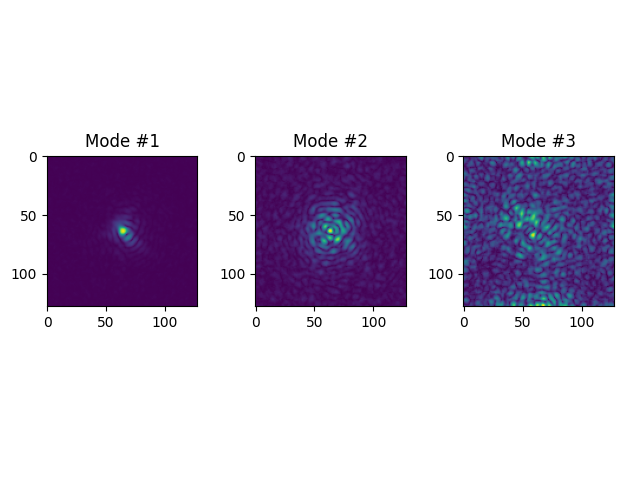

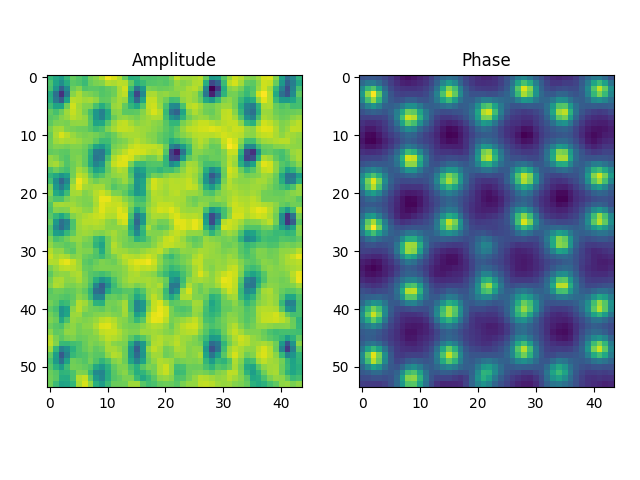

In [25]:
os.chdir(path)
#### Plotting
prev_recon_name = results_dir + "/mos2_" + result_dir_extra0+ "_" + result_dir_extra_mixed + "/" +  "recon_Niter40" + ".mat"
prev_recon_data = sio.loadmat(prev_recon_name)
print(prev_recon_name)
obj = prev_recon_data['object']
probe = prev_recon_data['probes']
px = prev_recon_data['ppX']
py = prev_recon_data['ppY']
dx = prev_recon_data['dx_x']
print(np.shape(obj))
print("dx=",dx)
print(rot_angle_d)
obj_crop = postProcess.postProcess(obj, rot_angle_d, px, py, dx)

print(np.shape(obj_crop))
print(probe.shape[0])
fig0, ax0 = plt.subplots(nrows=1, ncols=probe.shape[0])
fig0.tight_layout()
for jj in range(probe.shape[0]):
    ax0[jj].imshow(np.abs(probe[jj,:,:]))
    ax0[jj].set_title('Mode #' + str(jj+1) ) 
    
fig1, ax1 = plt.subplots(nrows=1, ncols=2)
fig1.tight_layout()
ax1[0].imshow(np.abs(obj_crop))
ax1[0].set_title('Amplitude')      
ax1[1].imshow(np.angle(obj_crop) )
ax1[1].set_title('Phase') 

[go to top](#toc)